In [1]:
from functions.clustering_functions import clustering_optimal_number, modularity_density
from functions.plots import plot_PDens_Q
from functions.main_functions import load_presaved_data, normal_run, run_squic_fit, run_squic, ask_yes_no
from functions.cosmograph_functions import visualize_graph_amlsim

In [2]:
user_input = ask_yes_no("\nDo you want to load data?")



In [3]:
results_squic = {}

name = 'AMLSIM'

if user_input == 'Y':
    Y_norm, knn_matrix, account_prop, dimension = load_presaved_data(name)

else: # Normal run
    Y_norm, knn_matrix, account_prop, dimension = normal_run(name)

results_squic = {}

# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':
    results_squic, squic_method, save = run_squic_fit(Y_norm, knn_matrix, results_squic, name, dimension)

else:
    results_squic, squic_method, save = run_squic(Y_norm, results_squic, name, dimension)

Head of Y_norm df:
          0             1         2         3         4         5         6  \
0  0.279429  2.794292e-01  0.384253  0.489077  0.489077  0.489077  0.489077   
1  0.142518  1.152051e-17  0.010036  0.010036  0.018062  0.018062  0.026088   
2  0.609647  6.096475e-01  0.609647  0.609647  0.853103  0.243499  0.285984   
3  0.251678  2.516778e-01  0.276428  0.276428  0.276428  0.276428  0.276428   
4  1.137171  1.375396e+00  1.468549  1.468549  2.136344  1.538752  1.538752   

          7         8         9  ...       190       191       192       193  \
0  0.567176  0.567176  0.567176  ... -2.197391 -2.197391 -2.092568 -1.987744   
1  0.026088  0.026088  0.026088  ... -3.099343 -3.099343 -3.099343 -3.241861   
2  0.285984 -0.122650 -0.122650  ... -3.947603 -3.947603 -3.947603 -3.947603   
3  0.276428  0.356315  0.436203  ... -1.977817 -1.858705 -1.858705 -1.858705   
4  1.538752  1.538752  1.776976  ...  4.806399  5.172990  5.172990  5.172990   

        194       195    

Is G connected for l=0.2? True
Is G connected for l=0.1? True
Is G connected for l=0.09? True
Is G connected for l=0.05? True
Is G connected for l=0.01? True
For rho 0.2:
    louvain: PDensity = 0.48, Int Density = 0.55, Q = 0.52, nCluster = 4, nIsolated  = 0
    leiden: PDensity = 0.56, Int Density = 0.66, Q = 0.52, nCluster = 5, nIsolated  = 0
    dbscan: PDensity = 0.36, Int Density = 0.13, Q = 0.46, nCluster = 6, nIsolated  = 4
    spectral: PDensity = 0.35, Int Density = 0.38, Q = 0.47, nCluster = 2, nIsolated  = 0
For rho 0.1:
    louvain: PDensity = 0.41, Int Density = 0.53, Q = 0.52, nCluster = 4, nIsolated  = 0
    leiden: PDensity = 0.42, Int Density = 0.51, Q = 0.52, nCluster = 4, nIsolated  = 0
    dbscan: PDensity = 0.28, Int Density = 0.08, Q = 0.43, nCluster = 9, nIsolated  = 7
    spectral: PDensity = 0.28, Int Density = 0.32, Q = 0.45, nCluster = 2, nIsolated  = 0
For rho 0.09:
    louvain: PDensity = 0.39, Int Density = 0.51, Q = 0.51, nCluster = 4, nIsolated  = 0
   

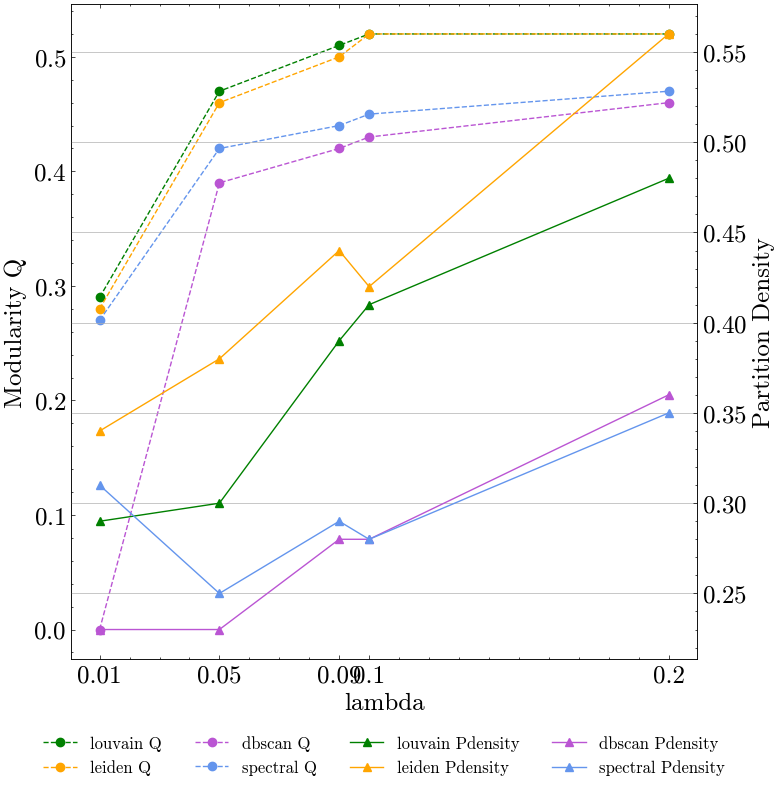

In [4]:
# Results
dict_cluster = clustering_optimal_number(dimension, results_squic, plot=False)

metrics = modularity_density(dict_cluster, results_squic, leiden=True)

for rho, data in metrics.items():
    print(f"For rho {rho}:")
    for method, results in data.items():
        print(f"    {method}: PDensity = {results['p_density']}, Int Density = {results['int_density']}, Q = {results['modularity']}, nCluster = {results['nCluster']}, nIsolated  = {results['isolated']}")

plot_PDens_Q(name, metrics, dimension, squic_method, save)

In [6]:
graph = visualize_graph_amlsim(results_squic, squic_method, dict_cluster, account_prop)

For rho 0.2, for louvain comm mapping is : {0: '0', 3: '0', 7: '0', 8: '0', 9: '0', 10: '0', 11: '0', 14: '0', 16: '0', 20: '0', 21: '0', 23: '0', 24: '0', 26: '0', 29: '0', 31: '0', 32: '0', 34: '0', 36: '0', 38: '0', 40: '0', 44: '0', 45: '0', 49: '0', 54: '0', 59: '0', 1: '1', 18: '1', 19: '1', 22: '1', 27: '1', 28: '1', 30: '1', 33: '1', 39: '1', 41: '1', 42: '1', 43: '1', 46: '1', 48: '1', 50: '1', 51: '1', 52: '1', 53: '1', 56: '1', 57: '1', 58: '1', 60: '1', 62: '1', 2: '2', 4: '2', 37: '2', 5: '2', 6: '2', 77: '2', 13: '2', 47: '2', 80: '2', 86: '2', 55: '2', 94: '2', 12: '3', 15: '3', 17: '3', 25: '3', 35: '3', 61: '3', 63: '3', 64: '3', 65: '3', 66: '3', 67: '3', 68: '3', 69: '3', 70: '3', 71: '3', 72: '3', 73: '3', 74: '3', 75: '3', 76: '3', 78: '3', 79: '3', 81: '3', 82: '3', 83: '3', 84: '3', 85: '3', 87: '3', 88: '3', 89: '3', 90: '3', 91: '3', 92: '3', 93: '3', 95: '3', 96: '3', 97: '3', 98: '3', 99: '3'}
For rho 0.1, for louvain comm mapping is : {0: '0', 3: '0', 7: '0'

In [7]:
lambda_graph = {
    '100': 0.09,
    '1K': 0.9999,
    '10K': 0.999999,
    '100K': 0.99999999
}

In [10]:
graph[lambda_graph.get(dimension)]['spectral']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…

In [11]:
graph[lambda_graph.get(dimension)]['leiden']

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…